# Objective
The purpose of the notebook is to present an analysis of real-time global issues like forest fires mainly in Turkey from the past 21 years. Through this analysis, patterns and observations are put together with the data of all the forest fire disasters that have taken place. The analysis keeps track of all the factors and observations influencing the fires to deliver a better understanding of this catastrophe. 

The following are the objectives of the project:
* Analyzing data to explore forest fire concentrated areas and factors impacting.
* To provide useful insights and visualization from the data collected.
* Build a detection model that produces warnings to fire breakouts
* Develop a prediction model to foresee the occurrence of forest fires with the data of the environmental conditions.
* Build an ensemble classifier model to improve the accuracy of the results.

# Working Methodology
This analysis has four sections:
* Data Processing and Exploratory Data Analysis
* Prediction Model
* Classification Model
* Detection Model

**Data Study**

About the dataset:

The dataset consists of all the forest fires that have occured in Turkey from 2000 to 2021. It contains a total of 211308 observations. Each observation consists of data of 15 factors:

* ‘latitude and longitude’: Geographical location of the fire hotspot.
* ‘brightness’: Brightness temperature measured in Kelvin using MODIS channels 21,22 and 31.
* ‘scan and track’: Actual spatial resolution
* ‘acq_date’: Data of active fire occurrence.
* ‘acq_time’: Time of active fire occurrence.
* ‘satellite’: Detection by Terra and Aqua satellites
* ‘instrument’: The MODIS instrument that tracks the observations is NASA’s Earth Observing System Terra and Aqua satellites. The orbit of the Terra satellite goes in the morning across the equator from north to south direction and Aqua passes in the same manner in the afternoon from south to north direction over the equator. This generates global coverage every 1 to 2 days. 
* ‘confidence’: Quality flag of individual active fire
* ‘version’: Processing collection and source of data
* ‘bright_t31’: Brightness Temperature in Kelvin of active fire
* ‘frp’: Fire Radiative power
* ‘daynight’: D for daytime fire and N for nighttime fire
* ‘type’: 0 for presumed vegetation fire, 1 for an active volcano, 2 for other static land sources, and 3 for offshore detection.



In [1]:
# import the data set
import pandas as pd
dataset = pd.read_csv("2000-2021 SINGLE TURKEY FIRE_M-C61_214067.csv")
dataset.head()

C:\Users\Goyal\AppData\Local\Temp\ipykernel_7060\684149776.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv("2000-2021 SINGLE TURKEY FIRE_M-C61_214067.csv")


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,36.8527,35.3594,306.0,2.1,1.4,2000-11-01,815,Terra,MODIS,60,6.03,294.4,13.2,D,0.0
1,40.5441,35.1786,307.8,1.1,1.0,2000-11-02,857,Terra,MODIS,66,6.03,296.0,5.8,D,0.0
2,40.1473,35.0444,305.3,1.1,1.0,2000-11-02,857,Terra,MODIS,46,6.03,293.5,4.3,D,0.0
3,40.5421,35.1909,310.0,1.1,1.0,2000-11-02,857,Terra,MODIS,69,6.03,296.1,7.3,D,0.0
4,41.2569,31.4172,307.9,1.1,1.0,2000-11-02,857,Terra,MODIS,0,6.03,290.4,8.0,D,2.0


In [2]:
dataset.describe()

,latitude,longitude,brightness,scan,track,acq_time,confidence,bright_t31,frp,type
count,211309.000000,211309.000000,211309.000000,211309.000000,211309.000000,211309.000000,211309.000000,211309.000000,211309.000000,205918.000000
mean,38.096869,35.810523,323.103487,1.519333,1.183241,1127.559252,66.453923,302.475387,30.341675,0.138798
std,1.259144,4.218867,15.710290,0.735847,0.228731,426.703297,19.297827,10.168149,67.171226,0.509481
min,35.822100,25.723600,300.000000,1.000000,1.000000,0.000000,0.000000,265.200000,0.000000,0.000000
25%,37.113200,33.037500,311.300000,1.000000,1.000000,845.000000,55.000000,294.100000,8.900000,0.000000
50%,37.711700,35.817400,322.100000,1.200000,1.100000,1024.000000,68.000000,302.800000,15.300000,0.000000
75%,38.931600,39.755500,331.300000,1.700000,1.300000,1110.000000,79.000000,310.000000,30.700000,0.000000
max,42.033000,44.796700,503.530000,4.820000,2.000000,2359.000000,100.000000,400.100000,4816.680000,3.000000


In [3]:
dataset.dtypes

latitude      float64
longitude     float64
brightness    float64
scan          float64
track         float64
acq_date       object
acq_time        int64
satellite      object
instrument     object
confidence      int64
version        object
bright_t31    float64
frp           float64
daynight       object
type          float64
dtype: object

In [4]:
# make a copy
data = dataset

In [5]:
#check on missing values
data.isna().sum()

latitude         0
longitude        0
brightness       0
scan             0
track            0
acq_date         0
acq_time         0
satellite        0
instrument       0
confidence       0
version          0
bright_t31       0
frp              0
daynight         0
type          5391
dtype: int64

<Axes: >

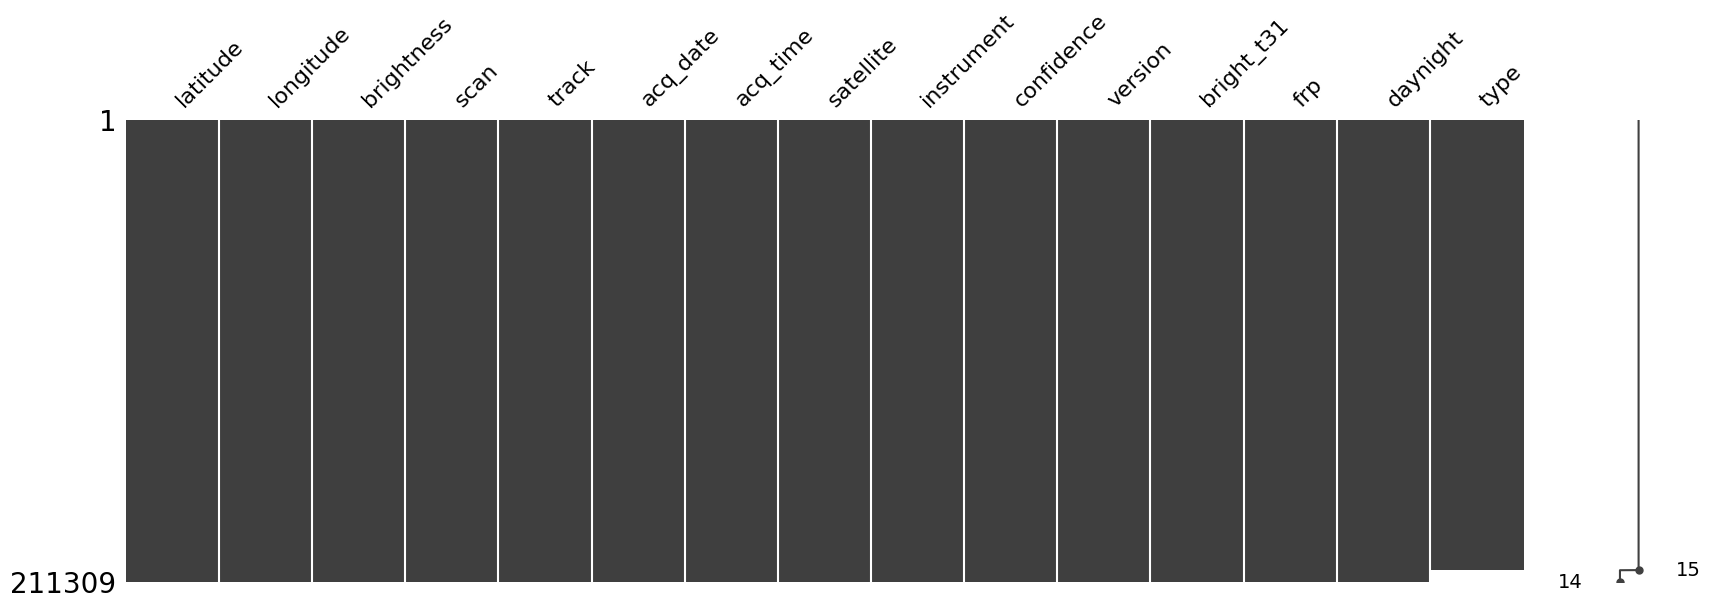

In [6]:
# vizualization of missing value locations
import missingno as mno
mno.matrix(data, figsize = (20, 6))

In [7]:
# split date to day, month and year
data[["Year", "Month", "Day"]] = data["acq_date"].str.split("-", expand = True)

In [8]:
# data types of all attributes
data.dtypes

latitude      float64
longitude     float64
brightness    float64
scan          float64
track         float64
acq_date       object
acq_time        int64
satellite      object
instrument     object
confidence      int64
version        object
bright_t31    float64
frp           float64
daynight       object
type          float64
Year           object
Month          object
Day            object
dtype: object

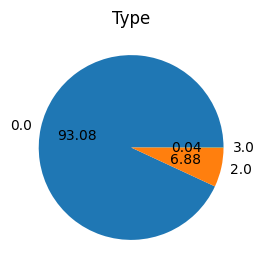

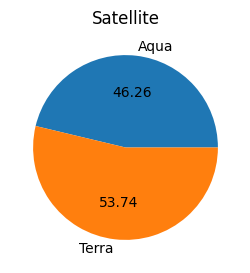

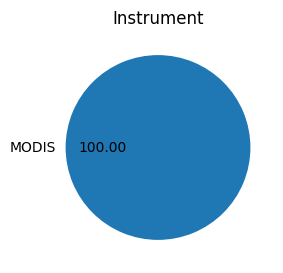

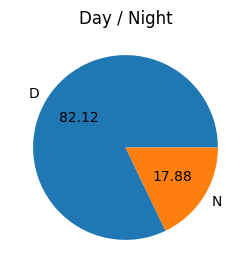

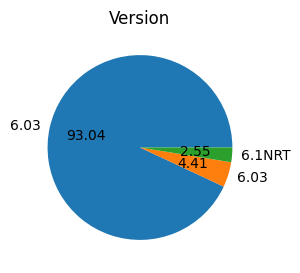

In [9]:
# plotting pie charts for all categorical columns
import matplotlib.pyplot as plt
plt.figure(0)
plt.title("Type")
data.groupby('type').size().plot(kind='pie', autopct='%.2f',figsize=(3, 3))
plt.figure(1)
plt.title("Satellite")
data.groupby('satellite').size().plot(kind='pie', autopct='%.2f',figsize=(3, 3))
plt.figure(2)
plt.title("Instrument")
data.groupby('instrument').size().plot(kind='pie', autopct='%.2f',figsize=(3, 3))
plt.figure(3)
plt.title("Day / Night")
data.groupby('daynight').size().plot(kind='pie', autopct='%.2f',figsize=(3, 3))
plt.figure(4)
plt.title("Version")
data.groupby('version').size().plot(kind='pie', autopct='%.2f',figsize=(3, 3))
plt.show() #show all figures

In [10]:
# drop instrument column
data = data.drop(['instrument'], axis = 1)
# converting categorical attributes to our target data type form
data["version"]= data["version"].astype(str)
data["Year"]= data["Year"].astype(int)
data["Month"]= data["Month"].astype(int)
data["Day"]= data["Day"].astype(int)
# add leading zeroes to time and convert
data['acq_time']=data['acq_time'].apply(lambda x: '{0:0>4}'.format(x))
data["acq_time"]= data["acq_time"].astype(int)

In [11]:
# convert object columns to numrical columns through encoding
from sklearn.preprocessing import LabelEncoder
l = LabelEncoder()
data['satellite']=l.fit_transform(data['satellite'])
data['daynight']=l.fit_transform(data['daynight'])
data['version']=l.fit_transform(data['version'])
data["version"]= data["version"].astype(int)

In [12]:
# final check on the data types - converted to numerical form
data.dtypes

latitude      float64
longitude     float64
brightness    float64
scan          float64
track         float64
acq_date       object
acq_time        int64
satellite       int64
confidence      int64
version         int64
bright_t31    float64
frp           float64
daynight        int64
type          float64
Year            int64
Month           int64
Day             int64
dtype: object

In [13]:
# min max feature scaling - optimize the data
def minmax(column):
    data[column] = (data[column] - data[column].min()) / (data[column].max() - data[column].min())    

minmax('bright_t31')
minmax('brightness')
minmax('frp')

Let's us take a look of the formatted data

In [14]:
data.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,confidence,version,bright_t31,frp,daynight,type,Year,Month,Day
0,36.8527,35.3594,0.029480,2.1,1.4,2000-11-01,815,1,60,0,0.216457,0.002740,0,0.0,2000,11,1
1,40.5441,35.1786,0.038324,1.1,1.0,2000-11-02,857,1,66,0,0.228317,0.001204,0,0.0,2000,11,2
2,40.1473,35.0444,0.026040,1.1,1.0,2000-11-02,857,1,46,0,0.209785,0.000893,0,0.0,2000,11,2
3,40.5421,35.1909,0.049133,1.1,1.0,2000-11-02,857,1,69,0,0.229059,0.001516,0,0.0,2000,11,2
4,41.2569,31.4172,0.038815,1.1,1.0,2000-11-02,857,1,0,0,0.186805,0.001661,0,2.0,2000,11,2


In [15]:
data1 = data.drop(['acq_date'], axis = 1)

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [17]:
train_data = data1.dropna()
test_data = data1[data1.isnull().any(axis=1)]
x_train = train_data.drop(['type'], axis = 1)
y_train = train_data['type']
x_test = test_data.drop(['type'], axis = 1)
y_test = test_data['type']
# fitting data into the model
model = LogisticRegression(solver='liblinear', random_state=0)
model.fit(x_train, y_train)

c:\Users\Goyal\OneDrive\Desktop\Satellite_Change_Detection\venv\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [18]:
# accuracy of our model
model.score(x_train, y_train)

0.9305937314853485

In [19]:
# probability of target variable being type 0,2 or 3
model.predict_proba(x_test) 

array([[6.97841799e-01, 3.01587143e-01, 5.71058156e-04],
       [9.68810742e-01, 3.11889679e-02, 2.90462301e-07],
       [8.43713810e-01, 1.56062732e-01, 2.23458079e-04],
       ...,
       [9.49676635e-01, 4.77391951e-02, 2.58416977e-03],
       [9.73083698e-01, 2.27293407e-02, 4.18696139e-03],
       [9.21728006e-01, 6.98390255e-02, 8.43296874e-03]], shape=(5391, 3))

In [20]:
y_pred = model.predict(x_test)
# convert to fit to df form 
y_pred = pd.DataFrame(y_pred)
y_pred

,0
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
5386,0.0
5387,0.0
5388,0.0
5389,0.0


In [21]:
# replacing the missing values with predicted values
test_data['type'] = y_pred.values

C:\Users\Goyal\AppData\Local\Temp\ipykernel_7060\1954042415.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['type'] = y_pred.values


In [22]:
test_data

,latitude,longitude,brightness,scan,track,acq_time,satellite,confidence,version,bright_t31,frp,daynight,type,Year,Month,Day
205918,41.05800,26.34300,0.134624,1.00,1.00,1120,0,85,1,0.167532,0.005003,0,0.0,2021,4,1
205919,40.22400,43.26000,0.077139,1.10,1.00,1020,0,74,1,0.209044,0.002388,0,0.0,2021,4,2
205920,38.95500,31.83300,0.115953,1.00,1.00,1105,0,81,1,0.235730,0.003716,0,0.0,2021,4,3
205921,36.92900,30.64500,0.064855,1.00,1.00,1105,0,59,1,0.244626,0.001391,0,0.0,2021,4,3
205922,37.16000,27.87800,0.029480,1.20,1.10,1105,0,50,1,0.214974,0.001370,0,0.0,2021,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211304,37.30414,43.69511,0.148872,1.02,1.01,1011,0,38,1,0.388288,0.002213,0,0.0,2021,8,10
211305,37.05791,27.28960,0.133838,1.96,1.37,1149,0,74,1,0.335063,0.005855,0,0.0,2021,8,10
211306,38.64441,27.08695,0.206112,2.00,1.38,1149,0,88,1,0.339214,0.018027,0,0.0,2021,8,10
211307,37.05018,28.84606,0.208323,2.48,1.52,1149,0,90,1,0.309489,0.029491,0,0.0,2021,8,10


In [23]:
test_data['type'].value_counts()

type
0.0    5266
2.0     125
Name: count, dtype: int64

# Complete Dataset

In [24]:
# merge train and test datasets
datasets = [train_data, test_data]
dataset = pd.concat(datasets)
dataset

,latitude,longitude,brightness,scan,track,acq_time,satellite,confidence,version,bright_t31,frp,daynight,type,Year,Month,Day
0,36.85270,35.35940,0.029480,2.10,1.40,815,1,60,0,0.216457,0.002740,0,0.0,2000,11,1
1,40.54410,35.17860,0.038324,1.10,1.00,857,1,66,0,0.228317,0.001204,0,0.0,2000,11,2
2,40.14730,35.04440,0.026040,1.10,1.00,857,1,46,0,0.209785,0.000893,0,0.0,2000,11,2
3,40.54210,35.19090,0.049133,1.10,1.00,857,1,69,0,0.229059,0.001516,0,0.0,2000,11,2
4,41.25690,31.41720,0.038815,1.10,1.00,857,1,0,0,0.186805,0.001661,0,2.0,2000,11,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211304,37.30414,43.69511,0.148872,1.02,1.01,1011,0,38,1,0.388288,0.002213,0,0.0,2021,8,10
211305,37.05791,27.28960,0.133838,1.96,1.37,1149,0,74,1,0.335063,0.005855,0,0.0,2021,8,10
211306,38.64441,27.08695,0.206112,2.00,1.38,1149,0,88,1,0.339214,0.018027,0,0.0,2021,8,10
211307,37.05018,28.84606,0.208323,2.48,1.52,1149,0,90,1,0.309489,0.029491,0,0.0,2021,8,10


In [25]:
dataset.dtypes

latitude      float64
longitude     float64
brightness    float64
scan          float64
track         float64
acq_time        int64
satellite       int64
confidence      int64
version         int64
bright_t31    float64
frp           float64
daynight        int64
type          float64
Year            int64
Month           int64
Day             int64
dtype: object

In [26]:
# final check on missing values
dataset.isna().sum()

latitude      0
longitude     0
brightness    0
scan          0
track         0
acq_time      0
satellite     0
confidence    0
version       0
bright_t31    0
frp           0
daynight      0
type          0
Year          0
Month         0
Day           0
dtype: int64

In [27]:
dataset.describe()

,latitude,longitude,brightness,scan,track,acq_time,satellite,confidence,version,bright_t31,frp,daynight,type,Year,Month,Day
count,211309.000000,211309.000000,211309.000000,211309.000000,211309.000000,211309.000000,211309.000000,211309.000000,211309.000000,211309.000000,211309.000000,211309.000000,211309.000000,211309.000000,211309.000000,211309.000000
mean,38.096869,35.810523,0.113514,1.519333,1.183241,1127.559252,0.537384,66.453923,0.025512,0.276319,0.006299,0.178786,0.136440,2011.349862,8.022914,15.829842
std,1.259144,4.218867,0.077189,0.735847,0.228731,426.703297,0.498602,19.297827,0.157676,0.075375,0.013946,0.383174,0.505442,5.408767,2.197637,9.030722
min,35.822100,25.723600,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2000.000000,1.000000,1.000000
25%,37.113200,33.037500,0.055520,1.000000,1.000000,845.000000,0.000000,55.000000,0.000000,0.214233,0.001848,0.000000,0.000000,2007.000000,6.000000,8.000000
50%,37.711700,35.817400,0.108584,1.200000,1.100000,1024.000000,1.000000,68.000000,0.000000,0.278725,0.003176,0.000000,0.000000,2011.000000,8.000000,16.000000
75%,38.931600,39.755500,0.153786,1.700000,1.300000,1110.000000,1.000000,79.000000,0.000000,0.332098,0.006374,0.000000,0.000000,2016.000000,10.000000,24.000000
max,42.033000,44.796700,1.000000,4.820000,2.000000,2359.000000,1.000000,100.000000,1.000000,1.000000,1.000000,1.000000,3.000000,2021.000000,12.000000,31.000000


<Axes: xlabel='longitude', ylabel='latitude'>

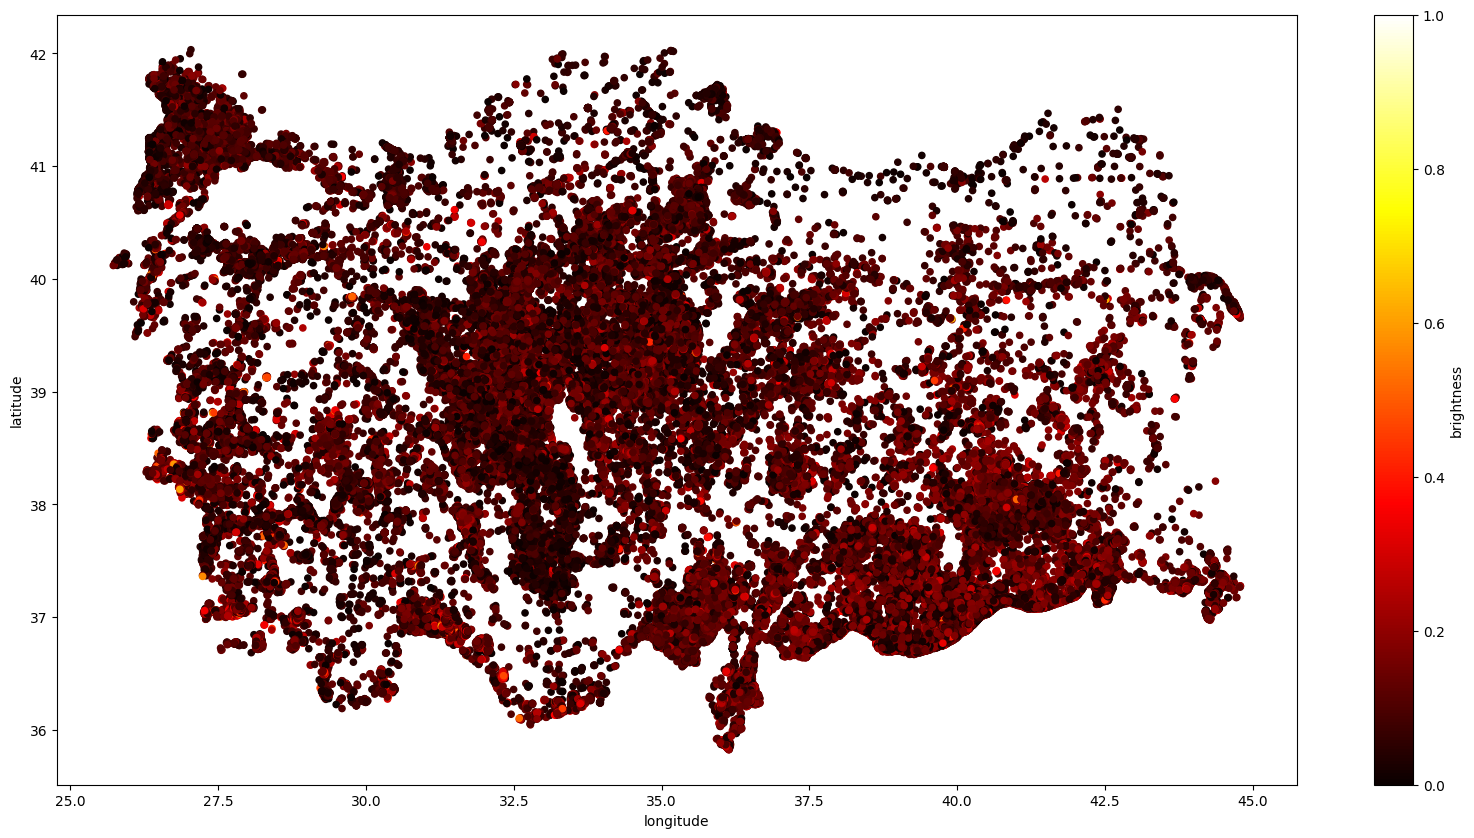

In [28]:
# loacation ploatting of all observations

dataset.plot(x="longitude", y="latitude", kind="scatter", c="brightness",
        colormap="hot",figsize=(20, 10))

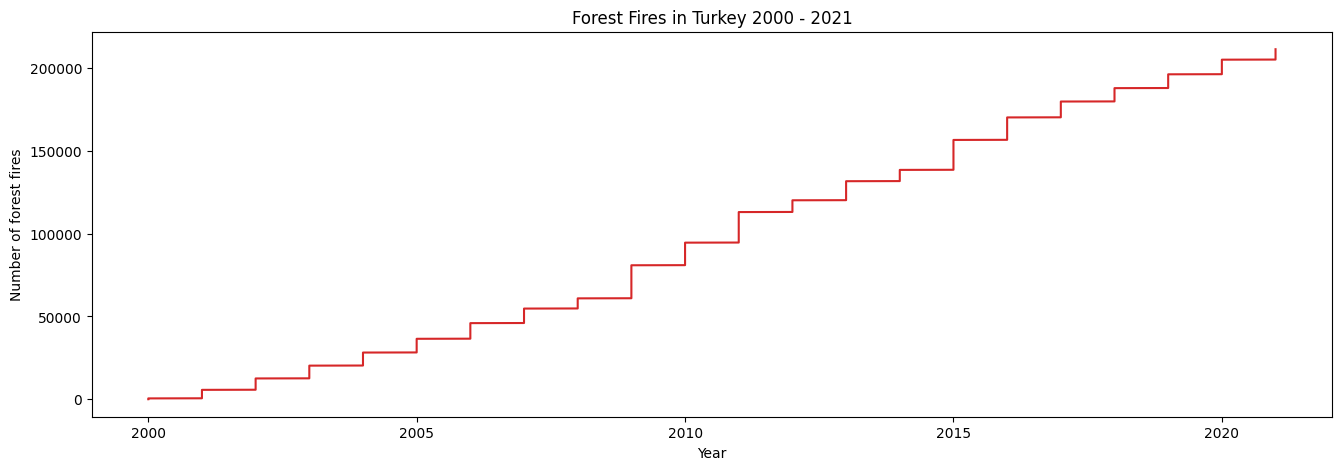

In [29]:
# Count of forest fires trends throught each year
def plottrend(data, x, y, title="", xlabel='Year', ylabel='Number of forest fires', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plottrend(dataset, x=dataset.Year, y=dataset.index, title='Forest Fires in Turkey 2000 - 2021')    

C:\Users\Goyal\AppData\Local\Temp\ipykernel_7060\754720118.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train_data.loc[train_data['daynight'] == 0, "Year"], shade=True, color="orange", label="Day", alpha=.7)
C:\Users\Goyal\AppData\Local\Temp\ipykernel_7060\754720118.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train_data.loc[train_data['daynight'] == 1, "Year"], shade=True, color="dodgerblue", label="Night", alpha=.7)


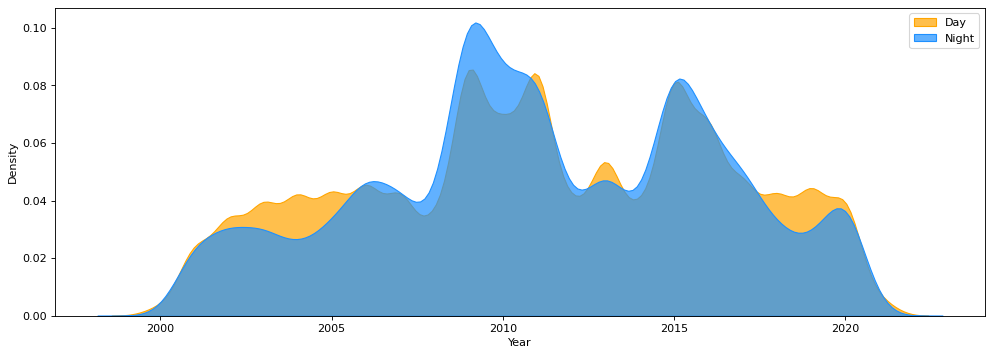

In [30]:
# density plot during the day and night
import seaborn as sns
plt.figure(figsize=(15,5), dpi= 80)
sns.kdeplot(train_data.loc[train_data['daynight'] == 0, "Year"], shade=True, color="orange", label="Day", alpha=.7)
sns.kdeplot(train_data.loc[train_data['daynight'] == 1, "Year"], shade=True, color="dodgerblue", label="Night", alpha=.7)
plt.legend()
plt.show()

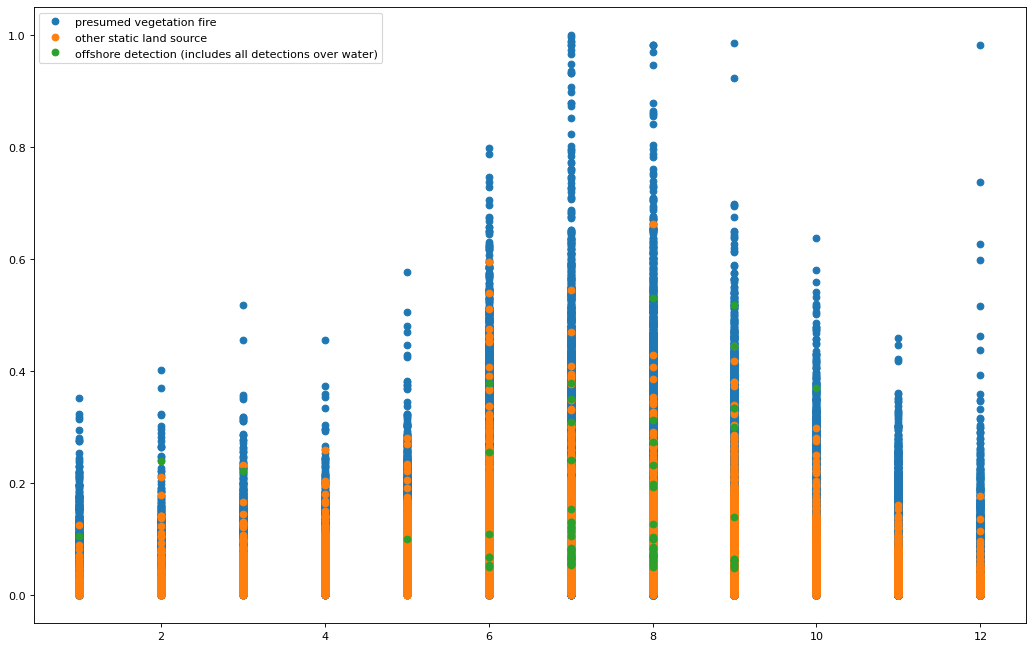

In [31]:
groups = dataset.groupby("type")
plt.figure(figsize=(16, 10), dpi= 80)
for name, group in groups:
    plt.plot(group["Month"], group["brightness"], marker="o", linestyle="", label=name)
plt.legend(['presumed vegetation fire', 'other static land source', 'offshore detection (includes all detections over water)'])

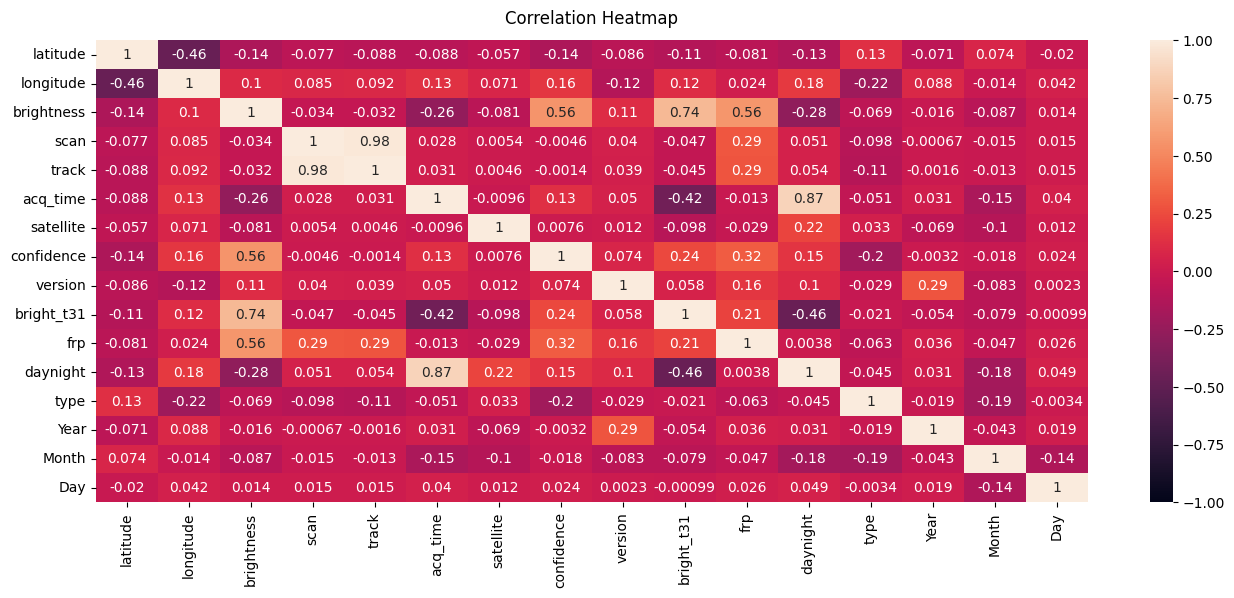

In [32]:
# correlation analysis
import seaborn as sns
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(dataset.corr(), vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12);

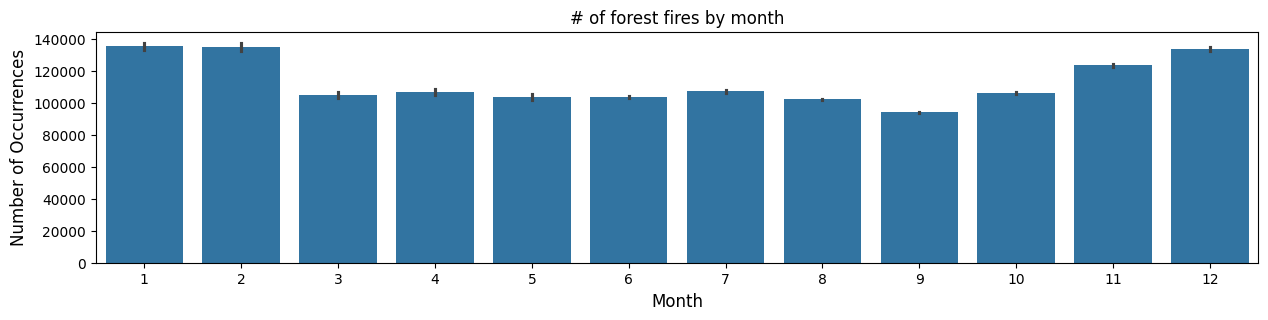

In [33]:
# number of forest fires by month
plt.figure(figsize=(15, 3))

plotdata = dataset

sns.barplot(x=plotdata.Month, y=plotdata.index)

plt.title('# of forest fires by month')
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Month', fontsize=12)

plt.show()

In [34]:
#dataset
X = dataset.drop(['type'], axis = 1)
y = dataset['type']

In [35]:
import six
import sys
sys.modules['sklearn.externals.six'] = six
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB 
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from mlxtend.classifier import StackingClassifier
import numpy as np

clf1 = KNeighborsClassifier(n_neighbors=1)
clf2 = RandomForestClassifier(random_state=1)
clf3 = GaussianNB()
clf4 = DecisionTreeClassifier()
lr = LogisticRegression()
sclf = StackingClassifier(classifiers=[clf1, clf2, clf3, clf4], 
                          meta_classifier=lr)

print('5-fold cross validation:\n')
results, names = list(), list()
for clf, label in zip([clf1, clf2, clf3, clf4, sclf], 
                      ['KNN', 
                       'Random Forest', 
                       'Naive Bayes',
                       'Decision Tree',
                       'StackingClassifier']):

    scores = model_selection.cross_val_score(clf, X, y, 
                                              cv=5, scoring='accuracy')
    results.append(scores)
    names.append(label)
    print("%s: %0.2f (%0.2f)" 
          % (label, scores.mean(), scores.std()))

5-fold cross validation:

KNN: 0.86 (0.03)
Random Forest: 0.78 (0.31)
Naive Bayes: 0.83 (0.03)
Decision Tree: 0.77 (0.33)
StackingClassifier: 0.96 (0.01)


In [36]:
import glob
import cv2
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix,classification_report

In [37]:
import glob

fire_images = glob.glob('Datasets/fire_images/*.png')

non_fire_images = glob.glob('Datasets/non_fire_images/*.png')

print("Fire Images:", len(fire_images))

print("Non Fire Images:", len(non_fire_images))

Fire Images: 244
Non Fire Images: 244


In [38]:
# create a mix of both fire and non fire images
import pandas as pd
fire_data = []
for x in fire_images:
  fire_data.append([x,1])
for x in non_fire_images:
  fire_data.append([x,0])
random.shuffle(fire_data)
fire_df = pd.DataFrame(fire_data,columns = ['Path','Fire/Non-Fire'])

In [39]:
# preprocess the images
def preprocessing_image(filepath):
  img = cv2.imread(filepath) #read
  img = cv2.cvtColor(img,cv2.COLOR_RGB2BGR) #convert
  img = cv2.resize(img,(196,196))  # resize
  img = img / 255 #scale
  return img 

def create_format_dataset(dataframe):
  X = []
  y = []
  for f,t in dataframe.values:
    X.append(preprocessing_image(f))
    y.append(t)
  return np.array(X),np.array(y)

X, y = create_format_dataset(fire_df)
X.shape,y.shape

((488, 196, 196, 3), (488,))

In [40]:
 # split dataset for training and testing
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,stratify = y)
model = Sequential()

model.add(Conv2D(128,(2,2),input_shape = (196,196,3),activation='relu'))
model.add(Conv2D(64,(2,2),activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(32,(2,2),activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dense(128))
model.add(Dense(1,activation= "sigmoid"))
model.summary()

c:\Users\Goyal\OneDrive\Desktop\Satellite_Change_Detection\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 195, 195, 128)  │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 194, 194, 64)   │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 97, 97, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 96, 96, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 73728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     9,437,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,480,161 (36.16 MB)

 Trainable params: 9,480,161 (36.16 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
import os
print(os.listdir("Datasets"))

['fire_images', 'non_fire_images']


In [42]:
callbacks = [EarlyStopping(monitor = 'val_loss',patience = 10,restore_best_weights=True)]
model.compile(optimizer='adam',loss = 'binary_crossentropy',metrics=['accuracy'])
model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs = 10,batch_size = 32,callbacks = callbacks)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 67s 5s/step - accuracy: 0.5865 - loss: 2.7955 - val_accuracy: 0.5578 - val_loss: 0.6288
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 74s 6s/step - accuracy: 0.8270 - loss: 0.3661 - val_accuracy: 0.9456 - val_loss: 0.1878
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 145s 13s/step - accuracy: 0.9091 - loss: 0.2164 - val_accuracy: 0.8231 - val_loss: 0.3255
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 141s 13s/step - accuracy: 0.9179 - loss: 0.2208 - val_accuracy: 0.9048 - val_loss: 0.2152
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 92s 8s/step - accuracy: 0.9677 - loss: 0.1042 - val_accuracy: 0.9184 - val_loss: 0.1532
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 171s 15s/step - accuracy: 0.9501 - loss: 0.1428 - val_accuracy: 0.9184 - val_loss: 0.2355
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 148s 13s/step - accuracy: 0.9736 - loss: 0.0888 - val_accuracy: 0.9116 - val_loss: 0.1845
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 300s 24s/step - accuracy: 0.9853 - loss: 0.0522 - val_accuracy: 0.9456 -

In [43]:
model.save("forest_fire_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [44]:
y_pred = model.predict(X_test)
y_pred = y_pred.reshape(-1)
y_pred[y_pred<0.5] = 0
y_pred[y_pred>=0.5] = 1
y_pred = y_pred.astype('int')
y_pred

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 801ms/step


array([0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0])

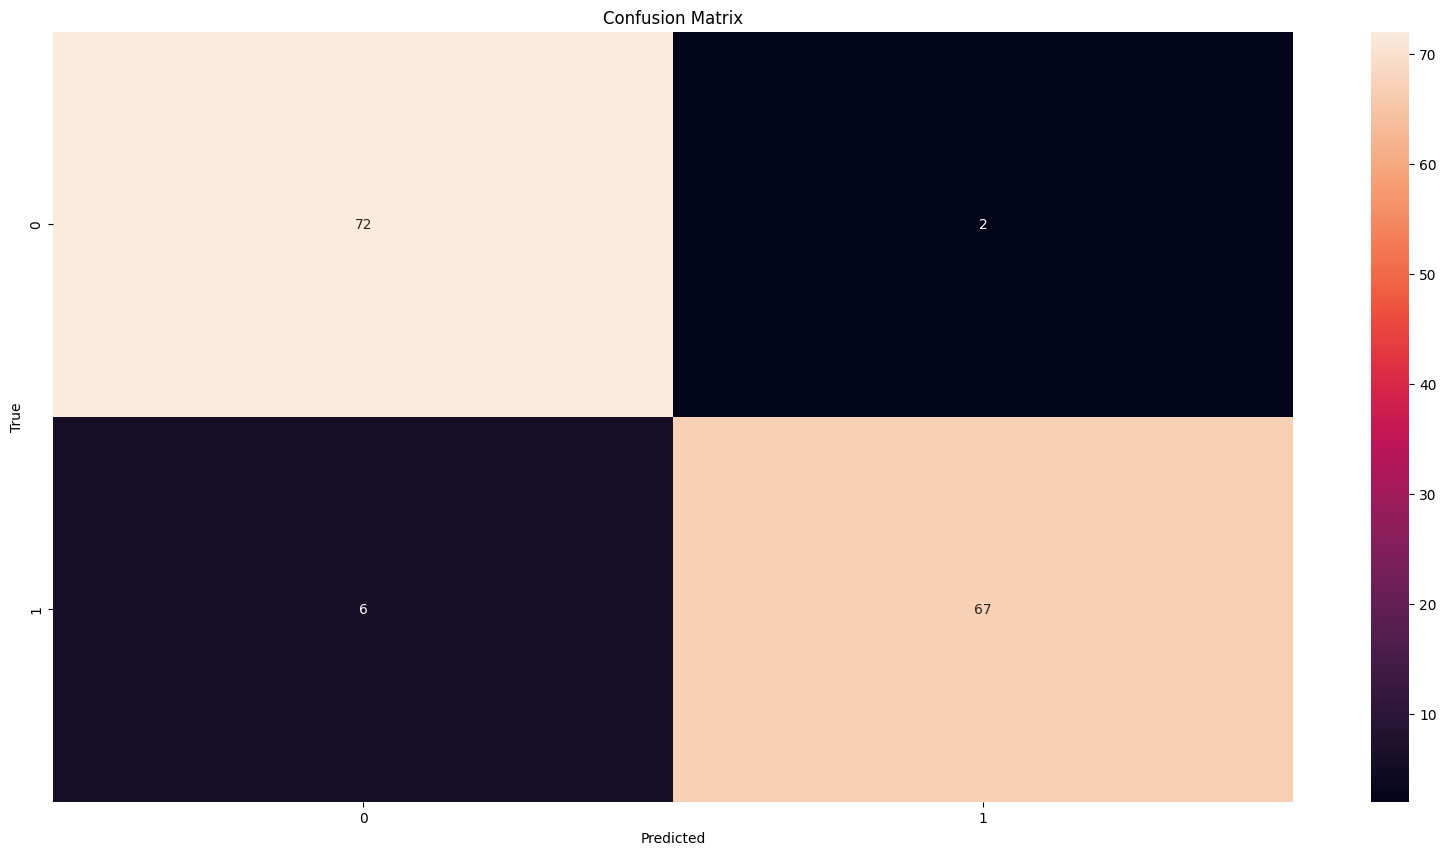

In [45]:
plt.figure(figsize = (20,10))

sns.heatmap(confusion_matrix(y_test,y_pred),annot = True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [46]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95        74
           1       0.97      0.92      0.94        73

    accuracy                           0.95       147
   macro avg       0.95      0.95      0.95       147
weighted avg       0.95      0.95      0.95       147



In [47]:
model.save("forest_fire_model.h5")